In [ ]:
%env CUDA_VISIBLE_DEVICES=7

env: CUDA_VISIBLE_DEVICES=7


### load data


In [2]:
from pathlib import Path
from dataset_3_mpm_genesis import build_asset_bank

dataset_root = Path("/data/gaoya/AAA_test_video/Dataset_test/Genesis_mpm_test")
physx_root = Path("/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet")
sophy_root = Path("/data/gaoya/dataset/SOPHY_data")
prepared_asset_root = Path("/data/gaoya/AAA_test_video/Dataset_test/Genesis_mpm_test/_prepared_assets")

In [12]:
import json
from dataset_3_mpm_genesis import prepare_articulation_asset

from physxnet_articulation_demo import (
    _configure_genesis_rigid_entity_from_metadata,
    _default_entity_rigid_material,
    _make_genesis_rigid_material,
    prepare_physxnet_object,
)



object_id = "39264"
version = "version_1"
voxel_pitch = 0.025
object_scale_mult = 1.0
force_rebuild_assets = True



# physx_bank = prepare_articulation_asset(
#     physx_root=physx_root,
#     version=version,
#     object_id=object_id,
#     prepared_asset_root=prepared_asset_root,
#     voxel_pitch=voxel_pitch,
#     object_scale_mult=object_scale_mult,
#     force_rebuild=force_rebuild_assets,
# )
import numpy as np

asset_dir = prepared_asset_root / object_id
meta_path = asset_dir / "meta" / "metadata.json"
prepare_physxnet_object(
    physx_root=physx_root,
    version=version,
    object_id=object_id,
    output_root=prepared_asset_root,
    voxel_pitch=voxel_pitch,
    object_scale_mult=object_scale_mult,
)

metadata = json.loads(meta_path.read_text(encoding="utf-8"))
bbox_min = np.asarray(metadata["object_bbox_min"], dtype=np.float64)
bbox_max = np.asarray(metadata["object_bbox_max"], dtype=np.float64)
bbox_extents = np.maximum(bbox_max - bbox_min, 1e-6)

rigid_count = len(metadata.get("rigid_part_links", []))
soft_count = len(metadata.get("soft_parts", []))



/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:302: RuntimeWarning: divide by zero encountered in divide
  center_mass = integrated[1:4] / volume
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:316: RuntimeWarning: invalid value encountered in scalar multiply
  integrated[5] + integrated[6] - (volume * (center_mass[[1, 2]] ** 2).sum())
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:319: RuntimeWarning: invalid value encountered in scalar multiply
  integrated[4] + integrated[6] - (volume * (center_mass[[0, 2]] ** 2).sum())
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:322: RuntimeWarning: invalid value encountered in scalar multiply
  integrated[4] + integrated[5] - (volume * (center_mass[[0, 1]] ** 2).sum())
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:324: RuntimeWarning: invalid value encountered in scalar mu

In [13]:
import json
json_path = "/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/finaljson/39264.json"
objs_dir = "/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/39264/objs"

with open(json_path, "r", encoding="utf-8") as f:
    meta = json.load(f)


In [17]:
print(json_path)

/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/finaljson/39264.json


In [19]:
print("/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/finaljson/277.json")

/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/finaljson/277.json


In [ ]:

def parse_group_info(group_info: Dict[str, Any]) -> Dict[str, Any]:
    parsed: Dict[str, Any] = {"base_group": group_info.get("0", [])}
    movable_groups: List[GroupRecord] = []
    for key, value in group_info.items():
        if key == "0":
            continue
        child_labels = list(value[0]) if isinstance(value[0], list) else [int(value[0])]
        parent_group = str(value[1])
        params = convert_joint_params_yup_to_zup(list(value[2]))
        joint_type = str(value[3])
        movable_groups.append(
            GroupRecord(
                group_id=str(key),
                child_labels=[int(x) for x in child_labels],
                parent_group=parent_group,
                params=params,
                joint_type=joint_type,
            )
        )
    parsed["movable_groups"] = movable_groups
    return parsed


    
parsed_groups = parse_group_info(meta.get("group_info", {}))


ensure_dir(out_dir)
ensure_dir(out_dir / "parts")
ensure_dir(out_dir / "rigid")
ensure_dir(out_dir / "soft")
ensure_dir(out_dir / "meta")
ensure_dir(out_dir / "scene_preview")

part_meshes: Dict[int, trimesh.Trimesh] = {}
part_phys: Dict[int, PartPhysical] = {}

for part in meta["parts"]:
    pid = int(part["label"])
    mesh_path = objs_dir / f"{pid}.obj"
    if not mesh_path.exists():
        continue
    mesh = load_mesh(mesh_path)
    mesh = yup_to_zup_mesh(mesh)
    part_meshes[pid] = mesh
    part_phys[pid] = build_part_physical(part, mesh_path)


NameError: name 'parse_group_info' is not defined

In [ ]:
def prepare_physxnet_object(
    physx_root: Path,
    version: str,
    object_id: str,
    output_root: Path,
    voxel_pitch: float,
    json_override: Optional[Path] = None,
    object_scale_mult: float = 1.0,
    fallback_density_kgm3: float = 800.0,
) -> PreparedObject:

    # ── 路径解析：确定 JSON 元数据文件和零件 OBJ 目录的路径 ──
    # version_root: PhysXNet 某版本的根目录，如 physx_root/version_1
    # json_path: 优先使用用户指定的 json_override，否则用默认路径
    # objs_dir: 每个零件的 OBJ 分割文件所在目录
    version_root = physx_root / version
    json_path = json_override if json_override is not None else version_root / "finaljson" / f"{object_id}.json"
    objs_dir = version_root / "partseg" / object_id / "objs"

    # 检查必要文件是否存在，不存在则提前报错
    if not json_path.exists():
        raise FileNotFoundError(json_path)
    if not objs_dir.exists():
        raise FileNotFoundError(objs_dir)

    # 加载 JSON 元数据（含部件物理属性、运动组信息等）
    # parse_group_info 将 group_info 解析为结构化的 base_group 和 movable_groups
    meta = _load_json(json_path)
    parsed_groups = parse_group_info(meta.get("group_info", {}))

    # ── 输出目录初始化：清空旧结果，创建各子目录 ──
    # parts/       存放原始零件 OBJ（Z-up，缩放后）
    # rigid/       存放 URDF、碰撞网格、局部坐标系网格
    # soft/        存放软体网格和粒子 npy
    # meta/        存放 metadata.json
    # scene_preview/ 存放场景预览（可选）
    out_dir = output_root / object_id
    if out_dir.exists():
        shutil.rmtree(out_dir)
    ensure_dir(out_dir)
    ensure_dir(out_dir / "parts")
    ensure_dir(out_dir / "rigid")
    ensure_dir(out_dir / "soft")
    ensure_dir(out_dir / "meta")
    ensure_dir(out_dir / "scene_preview")

    # ── 逐零件加载网格 + 物理参数 ──
    # part_meshes: 零件ID -> trimesh 网格对象（已转换为 Z-up 坐标系）
    # part_phys:   零件ID -> PartPhysical（密度、杨氏模量、泊松比、摩擦等）
    part_meshes: Dict[int, trimesh.Trimesh] = {}
    part_phys: Dict[int, PartPhysical] = {}

    for part in meta["parts"]:
        pid = int(part["label"])
        mesh_path = objs_dir / f"{pid}.obj"
        if not mesh_path.exists():   # 跳过缺失的零件文件
            continue
        mesh = load_mesh(mesh_path)
        mesh = yup_to_zup_mesh(mesh)   # Y-up → Z-up 坐标系转换（绕X轴旋转-90°）
        part_meshes[pid] = mesh
        part_phys[pid] = build_part_physical(part, mesh_path)  # 解析 JSON 中的物理参数

    if not part_meshes:
        raise ValueError(f"No valid part meshes found for object {object_id}")

    # ── 计算缩放因子，将网格归一化到物理真实尺寸 ──
    # 1. 合并所有零件网格，获取原始包围盒尺寸和中心点
    merged_raw = merge_meshes(list(part_meshes.values()))
    raw_extents = np.asarray(merged_raw.extents, dtype=np.float64)   # 原始网格三轴尺寸（无单位）
    raw_center = np.asarray(merged_raw.bounding_box.centroid, dtype=np.float64)  # 原始包围盒中心

    # 2. 从 JSON 的 dimension 字段解析真实物理尺寸（单位：米）
    #    dimension 字段格式如 "0.3*0.2*0.4 m"，对应 X/Y/Z 三轴
    dim_m = parse_dimension_to_meters(str(meta.get("dimension", "")))
    if dim_m is not None:
        # 将维度顺序从源 Y-up 约定转换为目标 Z-up 约定：[X, Y, Z] -> [X, Z, Y]
        dim_m = dim_m[[0, 2, 1]]
        # 缩放因子 = 真实最大尺寸 / 网格最大尺寸，使网格匹配真实物理尺度
        object_scale = float(np.max(dim_m) / max(np.max(raw_extents), 1e-8))
    else:
        # 没有 dimension 信息时，将最大轴归一化到 1 米
        object_scale = float(1.0 / max(np.max(raw_extents), 1e-8))

    # 应用用户传入的额外缩放倍数
    object_scale *= float(object_scale_mult)

    # 3. 对每个零件：平移到原点 → 缩放到物理尺度 → 清理网格 → 导出到 parts/ 目录
    for pid, mesh in list(part_meshes.items()):
        mesh = mesh.copy()
        mesh.apply_translation(-raw_center)   # 以整体包围盒中心为原点
        mesh.apply_scale(object_scale)        # 缩放到真实物理尺寸（米）
        mesh = sanitize_mesh(mesh)            # 修复退化面、重复顶点等问题
        part_meshes[pid] = mesh
        mesh.export(out_dir / "parts" / f"part_{pid:03d}.obj")

    # 4. 计算缩放后整体包围盒，用于接地偏移（让物体底部贴地）
    merged_scaled = merge_meshes(list(part_meshes.values()))
    bbox_min = np.asarray(merged_scaled.bounds[0], dtype=np.float64)  # 包围盒最小角（Z轴最低点）
    bbox_max = np.asarray(merged_scaled.bounds[1], dtype=np.float64)  # 包围盒最大角
    grounding_offset_z = float(-bbox_min[2])  # 将底部抬升到 Z=0 平面所需的偏移量

    # ── 零件分类：确定哪些是底座零件，哪些是可动零件 ──
    # base_group: JSON 中明确标注为固定底座的零件 ID 列表
    # movable_groups: 所有可动运动组（含子零件、关节类型、运动参数）
    # movable_child_labels: 所有被运动组管辖的零件 ID 集合
    # 最终 base_labels：原始底座零件 ∪ 未被任何运动组管辖的零件（孤立零件归底座）
    base_labels = sorted(int(x) for x in parsed_groups.get("base_group", []))
    movable_groups: List[GroupRecord] = parsed_groups.get("movable_groups", [])
    movable_child_labels = sorted({int(lbl) for g in movable_groups for lbl in g.child_labels})
    all_labels = sorted(part_meshes.keys())
    base_labels = sorted(set(base_labels).union(set(all_labels) - set(movable_child_labels)))

    # ── 创建 URDF XML 根节点和世界基础链接 ──
    # robot 是整个 URDF 的根元素
    # world_base 是一个质量极小的虚拟根链接，作为所有底座零件和运动组的挂载点
    robot = ET.Element("robot", attrib={"name": f"physxnet_{object_id}_strict"})
    world_base = ET.SubElement(robot, "link", name="world_base")
    add_inertial(world_base, 0.01, inertia_from_bbox(np.asarray([0.01, 0.01, 0.01]), 0.01))

    # ── 初始化各类零件的收集列表 ──
    rigid_part_links: List[Dict[str, Any]] = []    # 刚体零件链接信息
    rigid_group_carriers: List[Dict[str, Any]] = [] # 刚体运动组的载体链接信息
    soft_parts: List[Dict[str, Any]] = []           # 软体零件信息
    floating_parts: List[Dict[str, Any]] = []       # 未归类的孤立零件信息

    # group_anchor_world: 每个运动组在世界坐标系中的关节锚点位置
    # group_carrier_link: 每个运动组对应的 URDF carrier link 名称
    # 初始值：组0（底座组）锚点在原点，对应 world_base
    group_anchor_world: Dict[str, np.ndarray] = {"0": np.zeros(3, dtype=np.float64)}
    group_carrier_link: Dict[str, str] = {"0": "world_base"}

    # ── 为底座零件生成 URDF link + 固定关节 ──
    # 底座零件固定在 world_base 上（fixed joint），不会运动
    # 每个零件单独生成一个 link，保留独立颜色和质量
    base_part_ids = [pid for pid in base_labels if pid in part_meshes]
    for pid in base_part_ids:
        p = part_phys[pid]
        mesh = part_meshes[pid]
        link_name = f"base_part_{pid:03d}"
        visual_mesh_path = out_dir / "parts" / f"part_{pid:03d}.obj"

        # 用体素填充法生成碰撞网格（比原始网格更适合物理引擎）
        collision_mesh, collision_fill_meta = voxel_fill_mesh_collision(mesh, voxel_pitch)
        collision_mesh_path = out_dir / "rigid" / f"part_{pid:03d}_collision.obj"
        collision_mesh.export(collision_mesh_path)

        # URDF 中使用相对路径（相对于 rigid/ 目录）
        mesh_rel = os.path.relpath(visual_mesh_path, out_dir / "rigid")
        collision_mesh_rel = os.path.relpath(collision_mesh_path, out_dir / "rigid")

        # 创建 URDF link 节点，添加惯性参数和视觉/碰撞几何
        link = ET.SubElement(robot, "link", name=link_name)
        mass = _estimate_part_mass(mesh, p, fallback_density_kgm3)  # 根据体积×密度估算质量
        add_inertial(link, mass, inertia_from_bbox(np.asarray(mesh.extents), mass), xyz=_mesh_inertial_origin_xyz(mesh))
        add_mesh_visual_collision(
            link, mesh_rel, color_from_part_id(pid),
            collision_mesh_relpath=collision_mesh_rel,
            collision_friction=p.friction,
            collision_restitution=p.restitution,
        )

        # 创建固定关节：world_base → base_part_XXX
        joint = ET.SubElement(robot, "joint", name=f"fix_world_to_base_part_{pid:03d}", type="fixed")
        ET.SubElement(joint, "parent", link="world_base")
        ET.SubElement(joint, "child", link=link_name)
        ET.SubElement(joint, "origin", xyz="0 0 0", rpy="0 0 0")

        # 记录底座零件的完整元数据，供运行时使用
        rigid_part_links.append(
            {
                "part_id": pid,
                "link_name": link_name,
                "parent_link": "world_base",
                "group_id": "0",
                "mesh_path": str(visual_mesh_path),
                "collision_mesh_path": str(collision_mesh_path),
                "collision_voxel_fill": collision_fill_meta,
                "mesh_frame": "object_frame",
                "color_rgba": list(color_from_part_id(pid)),
                "mass_kg": float(mass),
                "density_kgm3": p.density_kgm3,
                "youngs_pa": p.youngs_pa,
                "poisson": p.poisson,
                "friction": p.friction,
                "restitution": p.restitution,
                "damping": p.damping,
                "simulator_material": p.simulator_material,
            }
        )

    # ── 预先为所有刚体运动组创建 carrier link，解析嵌套父子关系 ──
    # urdf_gen.py 的逻辑：关节锚点由 params[3:6] 决定，build_joint 内部处理偏移
    # carrier link 是一个质量极小的虚拟 link，作为运动关节的 child
    # 子零件通过 fixed joint 挂到 carrier 上
    rigid_groups_only: List[GroupRecord] = []
    for g in movable_groups:
        rigid_children = [pid for pid in g.child_labels if pid in part_meshes and part_phys[pid].simulator_material == "rigid"]
        if rigid_children:
            rigid_groups_only.append(g)
            group_carrier_link[g.group_id] = f"carrier_group_{g.group_id}"

    unresolved = {g.group_id: g for g in rigid_groups_only}
    progress = True
    while unresolved and progress:
        progress = False
        for gid in list(unresolved.keys()):
            g = unresolved[gid]
            if g.parent_group not in group_carrier_link:
                continue
            carrier_name = group_carrier_link[g.group_id]
            parent_link = group_carrier_link[g.parent_group]
            group_runtime = _group_runtime_joint_params(g.child_labels, part_phys)

            # carrier link：极轻虚拟节点，build_joint 内部会创建 abstract_ 中间 link
            # 注意：对于 C/D/CB 类型，build_joint 从 params[3:6] 读锚点，
            # origin_xyz 传 [0,0,0] 即可（锚点偏移在 build_joint 内部通过 abstract_ 处理）
            carrier = ET.SubElement(robot, "link", name=carrier_name)
            add_inertial(carrier, 0.01, inertia_from_bbox(np.asarray([0.01, 0.01, 0.01]), 0.01))
            joint_name = f"joint_group_{g.group_id}"
            build_joint(
                robot,
                parent_link,
                carrier_name,
                joint_name,
                g.joint_type,
                g.params,
                [0.0, 0.0, 0.0],   # 锚点已编码在 params[3:6] 中，origin 传零向量
                dynamics_damping=group_runtime["joint_damping"],
                dynamics_friction=group_runtime["joint_frictionloss"],
            )

            rigid_group_carriers.append(
                {
                    "group_id": g.group_id,
                    "joint_name": joint_name,
                    "carrier_link": carrier_name,
                    "parent_group": g.parent_group,
                    "parent_link": parent_link,
                    "joint_type": g.joint_type,
                    "joint_params": [float(x) for x in g.params],
                    "joint_damping": group_runtime["joint_damping"],
                    "joint_frictionloss": group_runtime["joint_frictionloss"],
                }
            )
            progress = True
            unresolved.pop(gid)

    if unresolved:
        raise RuntimeError(f"Could not resolve parent order for groups: {sorted(unresolved.keys())}")

    # ── 为各运动组的子零件生成 URDF link，挂载到对应 carrier ──
    # 严格按照 urdf_gen.py 逻辑：零件网格保持原始坐标（不做 anchor 偏移），
    # 每个子零件通过 fixed joint 直接挂到 carrier_group_X
    covered_labels = set(base_part_ids)
    for g in movable_groups:
        rigid_children = [pid for pid in g.child_labels if pid in part_meshes and part_phys[pid].simulator_material == "rigid"]
        soft_children = [pid for pid in g.child_labels if pid in part_meshes and part_phys[pid].simulator_material != "rigid"]
        if not rigid_children and not soft_children:
            continue

        carrier_name = group_carrier_link.get(g.group_id, "world_base")

        for pid in rigid_children:
            p = part_phys[pid]
            covered_labels.add(pid)
            # 零件网格使用原始坐标（parts/ 目录下已缩放的网格），不做 anchor 偏移
            visual_mesh_path = out_dir / "parts" / f"part_{pid:03d}.obj"
            mesh = part_meshes[pid]
            collision_mesh, collision_fill_meta = voxel_fill_mesh_collision(mesh, voxel_pitch)
            collision_mesh_path = out_dir / "rigid" / f"group_{g.group_id}_part_{pid:03d}_collision.obj"
            collision_mesh.export(collision_mesh_path)
            mesh_rel = os.path.relpath(visual_mesh_path, out_dir / "rigid")
            collision_mesh_rel = os.path.relpath(collision_mesh_path, out_dir / "rigid")

            link_name = f"group_{g.group_id}_part_{pid:03d}"
            link = ET.SubElement(robot, "link", name=link_name)
            mass = _estimate_part_mass(mesh, p, fallback_density_kgm3)
            add_inertial(
                link,
                mass,
                inertia_from_bbox(np.asarray(mesh.extents), mass),
                xyz=_mesh_inertial_origin_xyz(mesh),
            )
            add_mesh_visual_collision(
                link,
                mesh_rel,
                color_from_part_id(pid),
                collision_mesh_relpath=collision_mesh_rel,
                collision_friction=p.friction,
                collision_restitution=p.restitution,
            )

            # fixed joint：carrier → part（origin 0,0,0，网格坐标与 abstract_ 对齐由 build_joint 保证）
            j = ET.SubElement(robot, "joint", name=f"fix_carrier_{g.group_id}_part_{pid:03d}", type="fixed")
            ET.SubElement(j, "parent", link=carrier_name)
            ET.SubElement(j, "child", link=link_name)
            ET.SubElement(j, "origin", xyz="0 0 0", rpy="0 0 0")

            rigid_part_links.append(
                {
                    "part_id": pid,
                    "link_name": link_name,
                    "parent_link": carrier_name,
                    "group_id": g.group_id,
                    "mesh_path": str(visual_mesh_path),
                    "collision_mesh_path": str(collision_mesh_path),
                    "collision_voxel_fill": collision_fill_meta,
                    "mesh_frame": "object_frame",
                    "color_rgba": list(color_from_part_id(pid)),
                    "mass_kg": float(mass),
                    "density_kgm3": p.density_kgm3,
                    "youngs_pa": p.youngs_pa,
                    "poisson": p.poisson,
                    "friction": p.friction,
                    "restitution": p.restitution,
                    "damping": p.damping,
                    "simulator_material": p.simulator_material,
                }
            )

        # Soft children are exported individually with exact parameters; no averaging.
        for pid in soft_children:
            p = part_phys[pid]
            covered_labels.add(pid)
            mesh = part_meshes[pid]
            pts, fill_meta = voxel_fill_mesh(mesh, voxel_pitch)
            soft_mesh_path = out_dir / "soft" / f"soft_group_{g.group_id}_part_{pid:03d}.obj"
            pts_path = out_dir / "soft" / f"soft_group_{g.group_id}_part_{pid:03d}_particles.npy"
            mesh.export(soft_mesh_path)
            np.save(pts_path, pts)
            soft_parts.append(
                {
                    "group_id": g.group_id,
                    "part_id": pid,
                    "child_labels": [pid],
                    "mesh_path": str(soft_mesh_path),
                    "particles_path": str(pts_path),
                    "voxel_fill": fill_meta,
                    "material_model": p.simulator_material,
                    "density_kgm3": p.density_kgm3,
                    "youngs_pa": p.youngs_pa,
                    "poisson": p.poisson,
                    "friction": p.friction,
                    "restitution": p.restitution,
                    "damping": p.damping,
                    "joint_type": g.joint_type,
                    "joint_params": [float(x) for x in g.params],
                    "json_exact_parameters": p.json_exact_parameters,
                }
            )

    # Standalone labels not covered above.
    for pid in sorted(all_labels):
        if pid in covered_labels:
            continue
        p = part_phys[pid]
        mesh = part_meshes[pid]
        if p.simulator_material == "rigid":
            link_name = f"standalone_part_{pid:03d}"
            visual_mesh_path = out_dir / "parts" / f"part_{pid:03d}.obj"
            collision_mesh, collision_fill_meta = voxel_fill_mesh_collision(mesh, voxel_pitch)
            collision_mesh_path = out_dir / "rigid" / f"standalone_part_{pid:03d}_collision.obj"
            collision_mesh.export(collision_mesh_path)
            mesh_rel = os.path.relpath(visual_mesh_path, out_dir / "rigid")
            collision_mesh_rel = os.path.relpath(collision_mesh_path, out_dir / "rigid")
            link = ET.SubElement(robot, "link", name=link_name)
            mass = _estimate_part_mass(mesh, p, fallback_density_kgm3)
            add_inertial(link, mass, inertia_from_bbox(np.asarray(mesh.extents), mass), xyz=_mesh_inertial_origin_xyz(mesh))
            add_mesh_visual_collision(
                link,
                mesh_rel,
                color_from_part_id(pid),
                collision_mesh_relpath=collision_mesh_rel,
                collision_friction=p.friction,
                collision_restitution=p.restitution,
            )
            j = ET.SubElement(robot, "joint", name=f"fix_world_to_standalone_part_{pid:03d}", type="fixed")
            ET.SubElement(j, "parent", link="world_base")
            ET.SubElement(j, "child", link=link_name)
            ET.SubElement(j, "origin", xyz="0 0 0", rpy="0 0 0")
            floating_parts.append(
                {
                    "part_id": pid,
                    "link_name": link_name,
                    "mesh_path": str(visual_mesh_path),
                    "collision_mesh_path": str(collision_mesh_path),
                    "collision_voxel_fill": collision_fill_meta,
                    "material_model": "rigid",
                    "reason": "unassigned_by_group_info",
                    "density_kgm3": p.density_kgm3,
                    "youngs_pa": p.youngs_pa,
                    "poisson": p.poisson,
                    "friction": p.friction,
                    "json_exact_parameters": p.json_exact_parameters,
                }
            )
        else:
            pts, fill_meta = voxel_fill_mesh(mesh, voxel_pitch)
            soft_mesh_path = out_dir / "soft" / f"soft_part_{pid:03d}.obj"
            pts_path = out_dir / "soft" / f"soft_part_{pid:03d}_particles.npy"
            mesh.export(soft_mesh_path)
            np.save(pts_path, pts)
            soft_parts.append(
                {
                    "group_id": None,
                    "part_id": pid,
                    "child_labels": [pid],
                    "mesh_path": str(soft_mesh_path),
                    "particles_path": str(pts_path),
                    "voxel_fill": fill_meta,
                    "material_model": p.simulator_material,
                    "density_kgm3": p.density_kgm3,
                    "youngs_pa": p.youngs_pa,
                    "poisson": p.poisson,
                    "friction": p.friction,
                    "restitution": p.restitution,
                    "damping": p.damping,
                    "joint_type": None,
                    "joint_params": None,
                    "json_exact_parameters": p.json_exact_parameters,
                }
            )

    urdf_path = out_dir / "rigid" / f"{object_id}.urdf"
    indent_xml(robot)
    ET.ElementTree(robot).write(urdf_path, encoding="utf-8", xml_declaration=True)

    metadata = {
        "object_id": object_id,
        "object_name": meta.get("object_name", object_id),
        "category": meta.get("category", "Unknown"),
        "json_path_used": str(json_path),
        "dimension_raw": meta.get("dimension", None),
        "dimension_m": dim_m.tolist() if dim_m is not None else None,
        "object_scale": object_scale,
        "raw_mesh_extents": raw_extents.tolist(),
        "object_bbox_min": bbox_min.tolist(),
        "object_bbox_max": bbox_max.tolist(),
        "grounding_offset_z": grounding_offset_z,
        "base_part_labels": base_labels,
        "group_info": meta.get("group_info", {}),
        "rigid_group_carriers": rigid_group_carriers,
        "rigid_part_links": rigid_part_links,
        "soft_parts": soft_parts,
        "floating_parts": floating_parts,
        "parts_physical": {str(pid): asdict(p) for pid, p in part_phys.items()},
        "notes": {
            "coordinate_conversion": "source meshes and joint params are converted from Y-up to Z-up",
            "rigid_export": "rigid parts are exported per original part, never averaged or merged into a single colored group",
            "runtime_exactness": {
                "density": "used per rigid part to compute per-link mass/inertia and applied again to Genesis links after URDF load",
                "youngs_poisson": "used directly for soft-part Genesis materials; rigid bodies preserve them in metadata only because rigid contact models do not consume them directly",
                "friction_restitution_damping": "friction and restitution are written per rigid collision; friction and damping are also applied at runtime to rigid links / joints when Genesis exposes the corresponding setters",
            },
        },
    }
    with open(out_dir / "meta" / "metadata.json", "w", encoding="utf-8") as f:
        json.dump(metadata, f, ensure_ascii=False, indent=2)

    return PreparedObject(
        object_id=object_id,
        object_name=str(meta.get("object_name", object_id)),
        category=str(meta.get("category", "Unknown")),
        dimension_m=dim_m.tolist() if dim_m is not None else None,
        object_scale=object_scale,
        base_part_labels=base_labels,
        rigid_group_carriers=rigid_group_carriers,
        rigid_part_links=rigid_part_links,
        soft_parts=soft_parts,
        floating_parts=floating_parts,
        output_dir=str(out_dir),
        urdf_path=str(urdf_path),
        preview_video=None,
        grounding_offset_z=grounding_offset_z,
        object_bbox_min=bbox_min.tolist(),
        object_bbox_max=bbox_max.tolist(),
    )




NameError: name 'part_phys' is not defined

In [4]:
from dataset_3_mpm_genesis import build_sophy_asset_bank
sophy_bank = build_sophy_asset_bank(
    sophy_root=sophy_root,
    prepared_asset_root=prepared_asset_root,
    force_rebuild_assets=force_rebuild_assets,
    max_assets=5,
)

### build scene

In [5]:
asset_bank = sophy_bank
asset_bank = [physx_bank]

In [6]:
from dataset_3_utils_genesis import build_scene_generation_plan,sample_mpm_scene_cfg,export_scene
scene_plan_list = build_scene_generation_plan(1)# 每个场景一个样本
for local_idx, scene_plan in enumerate(scene_plan_list[0:], start=0):
    scene_idx = local_idx
    seed = scene_idx
    break

ImportError: cannot import name 'export_scene' from 'dataset_3_utils_genesis' (/home/gaoya/Code_Video/Code_data/dataset_3_utils_genesis.py)

In [ ]:


physx_scene_cfg = sample_scene_cfg(
    scene_idx,
    scene_plan=scene_plan,
    asset_bank=[physx_bank],
    seed=seed,
    target_seconds=None,
    target_numsteps=1000,
)
print(f"[INFO] exporting {physx_scene_cfg['scene_id']} | pattern={scene_cfg['pattern']} | n_objects={len(scene_cfg['objects'])}")


sophy_scene_cfg = sample_scene_cfg(
    scene_idx,
    scene_plan=scene_plan,
    asset_bank=sophy_bank,
    seed=seed,
    target_seconds=None,
    target_numsteps=1000,
)
print(f"[INFO] exporting {sophy_scene_cfg['scene_id']} | pattern={scene_cfg['pattern']} | n_objects={len(scene_cfg['objects'])}")
scene_cfg = physx_scene_cfg
scene_cfg = sophy_scene_cfg

In [37]:
from dataset_3_utils_dataset import build_urdf_from_json_file
urdf_root = Path("/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/urdf2")
output_root = Path("/data/gaoya/AAA_test_video/Dataset_physV/0330/")
json_override = None
version_root = physx_root / version

json_path = json_override if json_override is not None else version_root / "finaljson" / f"{object_id}.json"
objs_dir = version_root / "partseg" / object_id / "objs"

# 检查必要文件是否存在，不存在则提前报错
if not json_path.exists():
    raise FileNotFoundError(json_path)
if not objs_dir.exists():
    raise FileNotFoundError(objs_dir)

# ── 缓存检测：若 URDF 和 metadata 均已存在，直接读取返回，跳过重新生成 ──
out_dir = output_root / object_id
_cached_urdf = urdf_root / f"{object_id}.urdf"
_cached_meta = out_dir / "meta" / "metadata.json"
if _cached_urdf.exists() and _cached_meta.exists():
    with open(_cached_meta, "r", encoding="utf-8") as _f:
        _m = json.load(_f)
    print(f"[Cache] {object_id}: URDF already exists, loading from cache.")
    PreparedObject(
        object_id=_m["object_id"],
        object_name=_m["object_name"],
        category=_m["category"],
        dimension_m=_m.get("dimension_m"),
        object_scale=_m["object_scale"],
        base_part_labels=_m["base_part_labels"],
        rigid_group_carriers=_m["rigid_group_carriers"],
        rigid_part_links=_m["rigid_part_links"],
        soft_parts=_m["soft_parts"],
        floating_parts=_m["floating_parts"],
        output_dir=_m.get("output_dir", str(out_dir)),
        urdf_path=str(_cached_urdf),
        preview_video=None,
        grounding_offset_z=_m["grounding_offset_z"],
        object_bbox_min=_m.get("object_bbox_min", [0.0, 0.0, 0.0]),
        object_bbox_max=_m.get("object_bbox_max", [1.0, 1.0, 1.0]),
    )

# ── 若简化版 URDF（urdf2/）不存在，用 build_urdf_from_json_file 生成 ──
# 该版本供 urdf_browser 等工具预览使用，路径与 batch_generate_urdfs 一致
_simple_urdf_dir = urdf_root
_simple_urdf_path = _simple_urdf_dir / f"{object_id}.urdf"
if not _simple_urdf_path.exists():
    _simple_urdf_dir.mkdir(parents=True, exist_ok=True)
    _geopath = str(version_root / "partseg")
    build_urdf_from_json_file(
        jsonfile=str(json_path),
        index=object_id,
        geopath=_geopath,
        output_path=str(_simple_urdf_path),
        robot_name=object_id,
        mesh_rel_root="./../partseg",
    )
    print(f"[URDF] Simple URDF generated: {_simple_urdf_path}")


In [39]:
meta = _load_json(json_path)
parsed_groups = parse_group_info(meta.get("group_info", {}))

NameError: name '_load_json' is not defined

In [ ]:
from dataset_3_mpm_genesis import ensure_genesis_initialized
# scene, cam, entities, container_entities, state_specs, runtime_records, penetration_lift_records = build_scene(physx_scene_cfg)
gs = ensure_genesis_initialized(seed=0)

vis_options = gs.options.VisOptions(
    show_world_frame=False,
    show_link_frame=False,
    background_color=tuple(scene_cfg["background"]["background_color"]),
    ambient_light=tuple(scene_cfg["background"]["ambient_light"]),
    segmentation_level="entity",
    render_particle_as="sphere",
    particle_size_scale=1.0,
)
sim_options = gs.options.SimOptions(
    gravity=tuple(scene_cfg["sim_options"]["gravity"]),
    dt=scene_cfg["sim_options"]["dt"],
    substeps=scene_cfg["sim_options"]["substeps"],
)

In [ ]:


family = scene_cfg["family"]
if family != "rigid_only":
    raise ValueError(f"dataset_3_rigid_genesis only supports rigid_only scenes, got family={family}")

scene_kwargs = dict(
    sim_options=sim_options,
    vis_options=vis_options,
    show_viewer=False,
)


In [ ]:
scene, cam, entities, container_entities, state_specs, runtime_records, penetration_lift_records = build_scene(sophy_scene_cfg)

### physxnet_articulation_demo.py 仿真

In [11]:
from physxnet_articulation_demo import prepare_physxnet_object
from pathlib import Path


dataset_root = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready/")
physx_root = Path("/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet")
sophy_root = Path("/data/gaoya/dataset/SOPHY_data")
prepared_asset_root = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready/_prepared_assets")
prepared = prepare_physxnet_object(
    physx_root=Path(physx_root),
    version="version_1",
    object_id="277",
    output_root=Path(prepared_asset_root),
    voxel_pitch=0.025,
    json_override=None,
    object_scale_mult=1.0,

)



[URDF] Simple URDF generated: /data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/urdf2/277.urdf


In [4]:
import json
obj_dir = Path(prepared.output_dir)
metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))

use_mpm = len(metadata["soft_parts"]) > 0
use_mpm

False

In [ ]:

preview_video = simulate_in_genesis(
    prepared=prepared,
    output_root=Path(args.output_root),
    steps=int(args.steps),
    dt=float(args.dt),
    fps=int(args.fps),
    default_friction=float(args.default_friction),
    object_fixed=bool(args.object_fixed),
    striker_radius=float(args.striker_radius),
    striker_speed=float(args.striker_speed),
    args=args,
)

In [ ]:
import genesis as gs

########################## init ##########################
gs.init()

########################## create a scene ##########################

scene = gs.Scene(
    sim_options=gs.options.SimOptions(
        dt       = 4e-3,
        substeps = 10,
    ),
    mpm_options=gs.options.MPMOptions(
        lower_bound   = (-0.5, -1.0, 0.0),
        upper_bound   = (0.5, 1.0, 1),
    ),
    vis_options=gs.options.VisOptions(
        visualize_mpm_boundary = True,
    ),
    viewer_options=gs.options.ViewerOptions(
        camera_fov=30,
    ),
    show_viewer = True,
)

########################## entities ##########################
plane = scene.add_entity(
    morph=gs.morphs.Plane(),
)

obj_elastic = scene.add_entity(
    material=gs.materials.MPM.Elastic(),
    morph=gs.morphs.Box(
        pos  = (0.0, -0.5, 0.25),
        size = (0.2, 0.2, 0.2),
    ),
    surface=gs.surfaces.Default(
        color    = (1.0, 0.4, 0.4),
        vis_mode = 'visual',
    ),
)

obj_sand = scene.add_entity(
    material=gs.materials.MPM.Liquid(),
    morph=gs.morphs.Box(
        pos  = (0.0, 0.0, 0.25),
        size = (0.3, 0.3, 0.3),
    ),
    surface=gs.surfaces.Default(
        color    = (0.3, 0.3, 1.0),
        vis_mode = 'particle',
    ),
)

obj_plastic = scene.add_entity(
    material=gs.materials.MPM.ElastoPlastic(),
    morph=gs.morphs.Sphere(
        pos  = (0.0, 0.5, 0.35),
        radius = 0.1,
    ),
    surface=gs.surfaces.Default(
        color    = (0.4, 1.0, 0.4),
        vis_mode = 'particle',
    ),
)


########################## build ##########################
scene.build()

horizon = 1000
for i in range(horizon):
    scene.step()

In [1]:
import genesis as gs

########################## init ##########################
gs.init()

########################## create a scene ##########################
dt = 4e-3
substeps = 10

scene = gs.Scene(
    sim_options=gs.options.SimOptions(
        dt=dt,
        substeps=substeps,
    ),
    mpm_options=gs.options.MPMOptions(
        lower_bound=(-0.5, -1.0, 0.0),
        upper_bound=(0.5, 1.0, 1.0),
    ),
    vis_options=gs.options.VisOptions(
        visualize_mpm_boundary=True,
    ),
    viewer_options=gs.options.ViewerOptions(
        camera_fov=30,
    ),
    renderer=gs.renderers.Rasterizer(),   # 普通渲染足够快
    show_viewer=False,                    # 离屏渲染
)

########################## entities ##########################
plane = scene.add_entity(
    morph=gs.morphs.Plane(),
)

obj_elastic = scene.add_entity(
    material=gs.materials.MPM.Elastic(),
    morph=gs.morphs.Box(
        pos=(0.0, -0.5, 0.25),
        size=(0.2, 0.2, 0.2),
    ),
    surface=gs.surfaces.Default(
        color=(1.0, 0.4, 0.4),
        vis_mode='visual',
    ),
)

obj_sand = scene.add_entity(
    material=gs.materials.MPM.Liquid(),
    morph=gs.morphs.Box(
        pos=(0.0, 0.0, 0.25),
        size=(0.3, 0.3, 0.3),
    ),
    surface=gs.surfaces.Default(
        color=(0.3, 0.3, 1.0),
        vis_mode='particle',
    ),
)

obj_plastic = scene.add_entity(
    material=gs.materials.MPM.ElastoPlastic(),
    morph=gs.morphs.Sphere(
        pos=(0.0, 0.5, 0.35),
        radius=0.1,
    ),
    surface=gs.surfaces.Default(
        color=(0.4, 1.0, 0.4),
        vis_mode='particle',
    ),
)

########################## add camera ##########################
cam = scene.add_camera(
    res=(1280, 720),
    pos=(2.2, -2.2, 1.6),   # 相机位置
    lookat=(0.0, 0.0, 0.3), # 看向场景中心
    fov=30,
    GUI=False,
)

########################## build ##########################
scene.build()

########################## simulate + record ##########################
horizon = 1000
render_stride = 4   # 每4个物理步渲1帧，减小开销
video_fps = int(round(1.0 / (dt * render_stride)))  # 约 62 fps，对应真实仿真速度

cam.start_recording()

for i in range(horizon):
    scene.step()

    # 只按 stride 渲染，这样视频时长和物理时长基本一致
    if i % render_stride == 0:
        cam.render()

cam.stop_recording(
    save_to_filename="/home/gaoya/Code_Video/Code_data/vis/mpm_demo.mp4",
    fps=video_fps,
)

print(f"Saved video to mpm_demo.mp4, fps={video_fps}")

[I 03/31/26 02:21:34.387 1604257] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


[Genesis] [02:21:47] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [02:21:47] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [02:21:47] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [02:21:47] [INFO] Running on [NVIDIA GeForce RTX 4090] with backend gs.cuda. Device memory: 47.38 GB.
[Genesis] [02:21:47] [INFO] 🚀 Genesis initialized. 🔖 version: 0.4.0, 🎨 theme: dark, 🌱 seed: None, 🐛 debug: False, 📏 precision: 32, 🔥 performance: False, 💬 verbose: INFO
[Genesis] [02:21:50] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.
[Genesis] [02:21:50] [INFO] Scene <721a3f8> created.
[Genesis] [02:21:50] [INFO] Adding <gs.RigidEntity>. idx: 0, uid: <b7554d4>, morph: <gs.morphs.Plane>, material: <gs.materials.Rigid>.
[Genesis] [02:21:50] [INFO] Adding <gs.MPMEntity>. idx: 1, uid: <fe404b6>, morph: <gs.morphs.Box>, material: <

/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/quadrants/_test_tools/warnings_helper.py:11: UserWarning: cannot create weak reference to 'tuple' object. Template mapper caching disabled.
  warnings.warn(message)


[Genesis] [02:22:07] [INFO] Building visualizer...
[Genesis] [02:22:08] [INFO] Running at 6.24 FPS.
[Genesis] [02:22:08] [INFO] Running at 68.83 FPS.
[Genesis] [02:22:08] [INFO] Running at 68.87 FPS.
[Genesis] [02:22:08] [INFO] Running at 69.13 FPS.
[Genesis] [02:22:08] [INFO] Running at 69.37 FPS.
[Genesis] [02:22:08] [INFO] Running at 69.63 FPS.
[Genesis] [02:22:08] [INFO] Running at 69.86 FPS.
[Genesis] [02:22:09] [INFO] Running at 70.15 FPS.
[Genesis] [02:22:09] [INFO] Running at 70.40 FPS.
[Genesis] [02:22:09] [INFO] Running at 70.62 FPS.
[Genesis] [02:22:09] [INFO] Running at 70.86 FPS.
[Genesis] [02:22:09] [INFO] Running at 71.05 FPS.
[Genesis] [02:22:09] [INFO] Running at 71.25 FPS.
[Genesis] [02:22:09] [INFO] Running at 71.46 FPS.
[Genesis] [02:22:09] [INFO] Running at 71.68 FPS.
[Genesis] [02:22:09] [INFO] Running at 71.89 FPS.
[Genesis] [02:22:09] [INFO] Running at 72.04 FPS.
[Genesis] [02:22:09] [INFO] Running at 72.20 FPS.
[Genesis] [02:22:09] [INFO] Running at 72.34 FPS.


In [2]:
from pathlib import Path
from physxnet_articulation_demo import _collect_mpm_specs
import json
use_mpm = True
obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")

metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))
mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)

In [10]:
needs_mpm = True
mpm_lower = (-2.0, -1.5, -1.0)
mpm_upper = ( 2.0,  1.5,  2.0)
print("💛 fixed MPM lower =", mpm_lower)
print("💛 fixed MPM upper =", mpm_upper)
# print("💛 probe placed_pos =", placed_pos.tolist())
# print("💛 probe MPM lower  =", mpm_lower)
# print("💛 probe MPM upper  =", mpm_upper)
# print("💛 probe MPM AABB   =", mpm_gmin.tolist(), mpm_gmax.tolist())

scene_kwargs = dict(
    viewer_options=gs.options.ViewerOptions(
        camera_fov=30 if use_mpm else 40,
        **({} if use_mpm else {
            "camera_pos": (3.5, -1.0, 2.5),
            "camera_lookat": (0.0, 0.0, 0.5),
        })
    ),
    vis_options=gs.options.VisOptions(
        visualize_mpm_boundary=bool(needs_mpm),
    ),
)
scene_kwargs["sim_options"] = gs.options.SimOptions(
dt       = 4e-3,
substeps = 10,
)
scene = gs.Scene(**scene_kwargs)
scene.add_entity(
    morph=gs.morphs.Plane(),
    material=gs.materials.Rigid(rho=1200.0, friction=0.95),
)




💛 fixed MPM lower = (-2.0, -1.5, -1.0)
💛 fixed MPM upper = (2.0, 1.5, 2.0)
[Genesis] [02:28:36] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.
[Genesis] [02:28:36] [INFO] Scene <bae37e5> created.
[Genesis] [02:28:36] [INFO] Adding <gs.RigidEntity>. idx: 0, uid: <3117223>, morph: <gs.morphs.Plane>, material: <gs.materials.Rigid>.


───────────────────────── <gs.RigidEntity> ─────────────────────────
                   'n_qs': <int>: 0
                 'n_dofs': <int>: 0
                'n_links': <int>: 1
                'n_geoms': <int>: 1
                'n_cells': <numpy.int64>: 1119008
                'n_verts': <int>: 8
                'n_faces': <int>: 12
                'n_edges': <int>: 18
               'n_joints': <int>: 1
               'n_vgeoms': <int>: 1
               'n_vverts': <int>: 6
               'n_vfaces': <int>: 2
           'n_equalities': <int>: 0
                  'q_end': <int>: 0
                'q_start': <int>: 0
               'is_built': <bool>: False
            'is_attached': <bool>: False
'is_local_collision_mask': <bool>: False
                'dof_end': <int>: 0
              'dof_start': <int>: 0
                    'idx': <int>: 0
                    'sim': <gs.Simulator>
                    'uid': <gs.UID>('3117223-6d780469f9536c85fbf429c1b')
              'base_link': <g

In [ ]:
if use_mpm:
    for spec in mpm_specs:
        if spec["material_model"] == "elastoplastic":
            material = gs.materials.MPM.ElastoPlastic(
                E=spec["youngs"], nu=spec["poisson"], rho=spec["density"],   
                sampler='pbs',
            )
        else:
            material = gs.materials.MPM.Elastic(
                E=spec["youngs"], nu=spec["poisson"], rho=spec["density"],  
                sampler='pbs',
            )
        scene.add_entity(
            material=material,
            morph=gs.morphs.Mesh(
                file=spec["mesh_path"],
                scale=float(spec.get("scale", 1.0)),
                pos=tuple(placed_pos.tolist()),
                euler=tuple(spec.get("euler", (0.0, 0.0, 0.0))),
                file_meshes_are_zup=bool(spec.get("file_meshes_are_zup", True)),
            ),
            surface=gs.surfaces.Default(
                color=spec["color"],
                vis_mode="particle",
            ),
        )

### 39264

In [ ]:
from physxnet_articulation_demo import prepare_physxnet_object
from pathlib import Path


dataset_root = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_tst/")
physx_root = Path("/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet")
sophy_root = Path("/data/gaoya/dataset/SOPHY_data")
prepared_asset_root = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_tst/_prepared_assets")
prepared = prepare_physxnet_object(
    physx_root=Path(physx_root),
    version="version_1",
    object_id="39264",
    output_root=Path(prepared_asset_root),
    voxel_pitch=0.025,
    json_override=None,
    object_scale_mult=1.0,
    

)



[URDF] Simple URDF generated: /data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_None/urdf/39264.urdf
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid
❤️ solver_family: rigid, simulator_material: rigid


/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:302: RuntimeWarning: divide by zero encountered in divide
  center_mass = integrated[1:4] / volume
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:316: RuntimeWarning: invalid value encountered in scalar multiply
  integrated[5] + integrated[6] - (volume * (center_mass[[1, 2]] ** 2).sum())
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:319: RuntimeWarning: invalid value encountered in scalar multiply
  integrated[4] + integrated[6] - (volume * (center_mass[[0, 2]] ** 2).sum())
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:322: RuntimeWarning: invalid value encountered in scalar multiply
  integrated[4] + integrated[5] - (volume * (center_mass[[0, 1]] ** 2).sum())
/data/gaoya/miniconda3/envs/wan/lib/python3.10/site-packages/trimesh/triangles.py:324: RuntimeWarning: invalid value encountered in scalar mu

In [21]:
import genesis as gs
gs.init()
from pathlib import Path
from physxnet_articulation_demo import _collect_mpm_specs
import json
use_mpm = True
obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")

metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))
mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)




[Genesis] [04:43:56] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [04:43:56] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [04:43:56] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [04:43:56] [INFO] Running on [NVIDIA GeForce RTX 4090] with backend gs.cuda. Device memory: 47.38 GB.
[Genesis] [04:43:56] [INFO] 🚀 Genesis initialized. 🔖 version: 0.4.0, 🎨 theme: dark, 🌱 seed: None, 🐛 debug: False, 📏 precision: 32, 🔥 performance: False, 💬 verbose: INFO


In [10]:
mpm_specs[0]['file_meshes_are_zup']

False

💛 fixed MPM lower = (-2.0, -1.5, -1.0)
💛 fixed MPM upper = (2.0, 1.5, 2.0)
[Genesis] [04:05:16] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.
[Genesis] [04:05:16] [INFO] Scene <dea76c2> created.
[Genesis] [04:05:16] [INFO] Adding <gs.RigidEntity>. idx: 0, uid: <4571513>, morph: <gs.morphs.Plane>, material: <gs.materials.Rigid>.


[Genesis] [04:05:16] [INFO] Adding <gs.MPMEntity>. idx: 1, uid: <1cd2e00>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/parts/part_000.obj')>, material: <gs.materials.MPM.Elastic>.
[Genesis] [04:05:16] [INFO] Sampled 162,618 particles.
[Genesis] [04:05:16] [INFO] Adding <gs.MPMEntity>. idx: 2, uid: <9ffe150>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/parts/part_001.obj')>, material: <gs.materials.MPM.Elastic>.
[Genesis] [04:05:16] [INFO] Sampled 24,030 particles.
[Genesis] [04:05:16] [INFO] Adding <gs.MPMEntity>. idx: 3, uid: <a3c3000>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/parts/part_002.obj')>, material: <gs.materials.MPM.Elastic>.
[Genesis] [04:05:16] [INFO] Sampled 23,981 particles.
[Genesis] [04:05:16] [INFO] Adding <gs.MPMEntity>. idx: 4, uid: <fdbcb89>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_

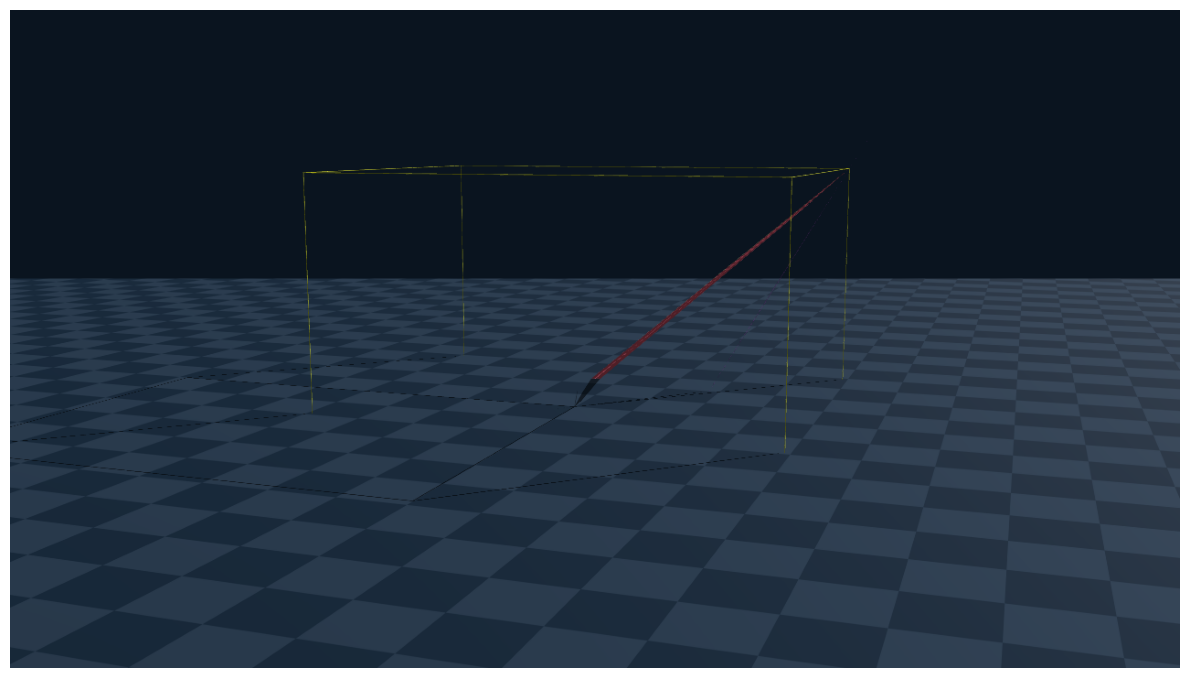

In [14]:

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ==========================
# 1) scene config
# ==========================
needs_mpm = True
use_mpm = True

mpm_lower = (-2.0, -1.5, -1.0)
mpm_upper = ( 2.0,  1.5,  2.0)

print("💛 fixed MPM lower =", mpm_lower)
print("💛 fixed MPM upper =", mpm_upper)

scene_kwargs = dict(
    viewer_options=gs.options.ViewerOptions(
        camera_fov=30 if use_mpm else 40,
        **({} if use_mpm else {
            "camera_pos": (3.5, -1.0, 2.5),
            "camera_lookat": (0.0, 0.0, 0.5),
        })
    ),
    vis_options=gs.options.VisOptions(
        visualize_mpm_boundary=bool(needs_mpm),
    ),
    sim_options=gs.options.SimOptions(
        dt=4e-3,
        substeps=10,
    ),
    renderer=gs.renderers.Rasterizer(),
    show_viewer=False,
)

if needs_mpm:
    scene_kwargs["mpm_options"] = gs.options.MPMOptions(
        lower_bound=mpm_lower,
        upper_bound=mpm_upper,
    )

scene = gs.Scene(**scene_kwargs)

# ==========================
# 2) add entities
# ==========================
scene.add_entity(
    morph=gs.morphs.Plane(),
    material=gs.materials.Rigid(rho=1200.0, friction=0.95),
)

if use_mpm:
    for spec in mpm_specs:
        if spec["material_model"] == "elastoplastic":
            material = gs.materials.MPM.ElastoPlastic(
                E=spec["youngs"],
                nu=spec["poisson"],
                rho=spec["density"],
                sampler="pbs",
            )
        else:
            material = gs.materials.MPM.Elastic(
                E=spec["youngs"],
                nu=spec["poisson"],
                rho=spec["density"],
                sampler="pbs",
            )

        scene.add_entity(
            material=material,
            morph=gs.morphs.Mesh(
                file=spec["mesh_path"],
                scale=float(spec.get("scale", 1.0)),
                euler=tuple(spec.get("euler", (0.0, 0.0, 0.0))),
                file_meshes_are_zup=bool(spec.get("file_meshes_are_zup", True)),
            ),
            surface=gs.surfaces.Default(
                color=spec["color"],
                vis_mode="visual",
            ),
        )

# ==========================
# 3) add offscreen camera
# ==========================
cam = scene.add_camera(
    res=(1280, 720),
    pos=(3.5, -10, 2.2),
    lookat=(0.0, 0.0, 0.5),
    fov=30 if use_mpm else 40,
    GUI=False,
)

# ==========================
# 4) build scene
# ==========================
scene.build()

for _ in range(5):
    scene.step()

# ==========================
# 5) render current scene to image
# ==========================
rgb, _, _, _ = cam.render(
    rgb=True,
    depth=False,
    segmentation=False,
    normal=False,
)

if hasattr(rgb, "detach"):
    rgb = rgb.detach().cpu().numpy()
rgb = np.asarray(rgb)

if rgb.dtype != np.uint8:
    rgb = np.clip(rgb, 0, 255).astype(np.uint8)

out_path = "/home/gaoya/Code_Video/Code_data/debug_scene.png"
Image.fromarray(rgb).save(out_path)
print(f"✅ saved image to: {out_path}")

plt.figure(figsize=(12, 7))
plt.imshow(rgb)
plt.axis("off")
plt.tight_layout()
plt.show()

In [13]:
spec["mesh_path"]

'/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/parts/part_014.obj'

In [16]:
import trimesh

mesh = trimesh.load(
    
    
    # mpm_specs[1]["mesh_path"],
    "/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_tst/_prepared_assets/39264/parts/part_001.obj", 
    force="mesh")
print("watertight:", mesh.is_watertight)
print("volume:", mesh.volume)
print("bounds:", mesh.bounds)
print("extents:", mesh.extents)

watertight: False
volume: 2.3129646346357427e-18
bounds: [[-0.01165664  0.07899939 -0.1367318 ]
 [ 0.63311198  0.28697867  0.21058227]]
extents: [0.64476862 0.20797928 0.34731407]


In [19]:
import json
import numpy as np
import genesis as gs



def build_mpm_material(spec, sampler="pbs"):
    model = spec.get("material_model", "elastic").lower()

    if model == "elastic":
        return gs.materials.MPM.Elastic(
            E=float(spec["youngs_pa"]),
            nu=float(spec["poisson"]),
            rho=float(spec["density_kgm3"]),
            sampler=sampler,
            model="corotation",
        )
    elif model in ["elastoplastic", "elasto_plastic"]:
        return gs.materials.MPM.ElastoPlastic(
            E=float(spec["youngs_pa"]),
            nu=float(spec["poisson"]),
            rho=float(spec["density_kgm3"]),
            sampler=sampler,
        )
    elif model == "liquid":
        return gs.materials.MPM.Liquid(
            rho=float(spec["density_kgm3"]),
            sampler=sampler,
        )
    elif model == "sand":
        return gs.materials.MPM.Sand(
            E=float(spec["youngs_pa"]),
            nu=float(spec["poisson"]),
            rho=float(spec["density_kgm3"]),
            sampler=sampler,
        )
    else:
        raise ValueError(f"Unsupported material_model: {model}")


def compute_mpm_bounds_from_soft_parts(meta, placed_pos=(0.0, 0.0, 0.0), extra_margin=0.20):
    """
    用 soft_parts 的真实粒子/mesh 范围来估计 MPM solver boundary，
    比 object_bbox_min/max 更稳。
    """
    placed_pos = np.array(placed_pos, dtype=float)

    mins = []
    maxs = []

    for spec in meta["soft_parts"]:
        particles_path = spec.get("particles_path", None)
        mesh_path = spec.get("mesh_path", None)

        if particles_path is not None and os.path.exists(particles_path):
            pts = np.load(particles_path)
            pts = np.asarray(pts, dtype=float)
            if pts.ndim != 2 or pts.shape[1] != 3:
                raise ValueError(f"Invalid particles shape for {particles_path}: {pts.shape}")
            mins.append(pts.min(axis=0))
            maxs.append(pts.max(axis=0))
        else:
            if mesh_path is None or (not os.path.exists(mesh_path)):
                raise FileNotFoundError(f"Neither valid particles_path nor mesh_path found for spec: {spec}")
            mesh = trimesh.load(mesh_path, force="mesh")
            bounds = np.asarray(mesh.bounds, dtype=float)  # shape (2, 3)
            mins.append(bounds[0])
            maxs.append(bounds[1])

    global_min = np.min(np.stack(mins, axis=0), axis=0) + placed_pos
    global_max = np.max(np.stack(maxs, axis=0), axis=0) + placed_pos

    lower = tuple((global_min - extra_margin).tolist())
    upper = tuple((global_max + extra_margin).tolist())
    return lower, upper


def build_partwise_mpm_scene_v3(
    metadata_path,
    sampler="pbs",
    dt=4e-3,
    substeps=10,
    show_viewer=False,
    extra_margin=0.20,
):
    with open(metadata_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    placed_pos = (0.0, 0.0, float(meta["grounding_offset_z"]))
    file_meshes_are_zup = True

    # 用 soft_parts 的真实范围算边界
    mpm_lower, mpm_upper = compute_mpm_bounds_from_soft_parts(
        meta,
        placed_pos=placed_pos,
        extra_margin=extra_margin,
    )

    print("💛 computed MPM lower =", mpm_lower)
    print("💛 computed MPM upper =", mpm_upper)

    scene = gs.Scene(
        sim_options=gs.options.SimOptions(
            dt=dt,
            substeps=substeps,
        ),
        mpm_options=gs.options.MPMOptions(
            # lower_bound=mpm_lower,
            # upper_bound=mpm_upper,
        lower_bound   = (-1, -1.0, -0.5),
        upper_bound   = (1, 1.0, 2),


            
        ),
        vis_options=gs.options.VisOptions(
            visualize_mpm_boundary=True,
        ),
        viewer_options=gs.options.ViewerOptions(
            camera_fov=30,
        ),
        renderer=gs.renderers.Rasterizer(),
        show_viewer=show_viewer,
    )

    scene.add_entity(
        morph=gs.morphs.Plane(),
        material=gs.materials.Rigid(rho=1200.0, friction=0.95),
    )

    color_map = {
        int(x["part_id"]): tuple(x.get("color_rgba", [0.7, 0.7, 0.7, 1.0]))
        for x in meta.get("rigid_part_links", [])
    }

    name_map = {
        int(v["part_id"]): v.get("name", f"part_{k}")
        for k, v in meta.get("parts_physical", {}).items()
    }

    part_entities = {}
    for spec in meta["soft_parts"]:
        pid = int(spec["part_id"])
        material = build_mpm_material(spec, sampler=sampler)

        ent = scene.add_entity(
            name=name_map.get(pid, f"mpm_part_{pid}"),
            material=material,
            morph=gs.morphs.Mesh(
                file=spec["mesh_path"],
                scale=1.0,
                pos=placed_pos,
                euler=(0.0, 0.0, 0.0),
                file_meshes_are_zup=file_meshes_are_zup,
            ),
            surface=gs.surfaces.Default(
                color=color_map.get(pid, (0.7, 0.7, 0.9, 1.0)),
                vis_mode="particle",
            ),
        )
        part_entities[pid] = ent

    # scene.build()
    return scene, part_entities, meta


    

In [44]:

dt = 4e-3
substeps = 10

scene, part_entities, meta = build_partwise_mpm_scene_v3(
    metadata_path="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/meta/metadata.json",
    sampler="pbs",
    dt=dt,
    substeps=substeps,
    show_viewer=False,
    extra_margin=0.20,
)

cam = scene.add_camera(
    res=(1280, 720),
    pos=(2.8, -2.2, 1.8),
    lookat=(0.0, 0.0, 0.6),
    fov=30,
    GUI=False,
)

scene.build()

horizon = 200
render_stride = 2
video_fps = int(round(1.0 / (dt * render_stride)))
save_path = "/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/render_277.mp4"

cam.start_recording()

for i in range(horizon):
    scene.step()
    if i % render_stride == 0:
        cam.render()

cam.stop_recording(
    save_to_filename=save_path,
    fps=video_fps,
)

print(f"✅ saved video to: {save_path}")

# scene, part_entities, meta = build_partwise_mpm_scene_v3(
#     metadata_path="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/meta/metadata.json",
#     sampler="pbs",
#     dt=4e-3,
#     substeps=10,
#     show_viewer=False,
#     extra_margin=0.20,
# )

# for _ in range(200):
#     scene.step()

💛 computed MPM lower = (-0.4750000059604645, -0.6000000059604644, -0.20000002384185794)
💛 computed MPM upper = (0.4750000059604645, 0.6000000059604644, 1.400000023841858)
[Genesis] [04:44:25] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.
[Genesis] [04:44:25] [INFO] Scene <f2f812b> created.
[Genesis] [04:44:25] [INFO] Adding <gs.RigidEntity>. idx: 0, uid: <88bc636>, morph: <gs.morphs.Plane>, material: <gs.materials.Rigid>.
[Genesis] [04:44:25] [INFO] Adding <gs.MPMEntity>. idx: 1, uid: <47993d4>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/soft/soft_rigid_part_000.obj')>, material: <gs.materials.MPM.Elastic>.
[Genesis] [04:44:25] [INFO] Sampled 28,892 particles.
[Genesis] [04:44:25] [INFO] Adding <gs.MPMEntity>. idx: 2, uid: <27fcd49>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet

In [50]:
def path_map(spec_mesh_path):
    objj = int(spec_mesh_path.split("_")[-1].split(".")[0])

    id = spec_mesh_path.split("/")[-3]
    path = f"/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/{id}/objs/{str(objj)}.obj"
    print(path)
    return path

def build_partwise_mpm_scene_v3(
    metadata_path,
    sampler="pbs",
    dt=4e-3,
    substeps=10,
    show_viewer=False,
    extra_margin=0.20,
):
    with open(metadata_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    placed_pos = (0.0, 0.0, float(meta["grounding_offset_z"]))
    file_meshes_are_zup = True

    # 用 soft_parts 的真实范围算边界
    mpm_lower, mpm_upper = compute_mpm_bounds_from_soft_parts(
        meta,
        placed_pos=placed_pos,
        extra_margin=extra_margin,
    )

    print("💛 computed MPM lower =", mpm_lower)
    print("💛 computed MPM upper =", mpm_upper)

    scene = gs.Scene(
        sim_options=gs.options.SimOptions(
            dt=dt,
            substeps=substeps,
        ),
        mpm_options=gs.options.MPMOptions(
            # lower_bound=mpm_lower,
            # upper_bound=mpm_upper,
        lower_bound   = (-2, -2, -0.5),
        upper_bound   = (1, 1.2, 2),


            
        ),
        vis_options=gs.options.VisOptions(
            visualize_mpm_boundary=True,
        ),
        viewer_options=gs.options.ViewerOptions(
            camera_fov=30,
        ),
        renderer=gs.renderers.Rasterizer(),
        show_viewer=show_viewer,
    )

    scene.add_entity(
        morph=gs.morphs.Plane(),
        material=gs.materials.Rigid(rho=1200.0, friction=0.95),
    )

    color_map = {
        int(x["part_id"]): tuple(x.get("color_rgba", [0.7, 0.7, 0.7, 1.0]))
        for x in meta.get("rigid_part_links", [])
    }

    name_map = {
        int(v["part_id"]): v.get("name", f"part_{k}")
        for k, v in meta.get("parts_physical", {}).items()
    }

    part_entities = {}
    for spec in meta["soft_parts"]:


        pid = int(spec["part_id"])
        material = build_mpm_material(spec, sampler=sampler)

        ent = scene.add_entity(
            name=name_map.get(pid, f"mpm_part_{pid}"),
            material=material,
            morph=gs.morphs.Mesh(
                file=path_map(spec["mesh_path"]),
                scale=1.0,
                pos=placed_pos,
                euler=(0.0, 0.0, 0.0),
                file_meshes_are_zup=file_meshes_are_zup,
            ),
            surface=gs.surfaces.Default(
                color=color_map.get(pid, (0.7, 0.7, 0.9, 1.0)),
                vis_mode="visual",
            ),
        )
        part_entities[pid] = ent

    # scene.build()
    return scene, part_entities, meta

dt = 4e-3
substeps = 10

scene, part_entities, meta = build_partwise_mpm_scene_v3(
    metadata_path="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/meta/metadata.json",
    sampler="pbs",
    dt=dt,
    substeps=substeps,
    show_viewer=False,
    extra_margin=0.20,
)

cam = scene.add_camera(
    res=(1280, 720),
    pos=(2.8, -2.2, 1.8),
    lookat=(0.0, 0.0, 0.6),
    fov=30,
    GUI=False,
)

scene.build()

horizon = 200
render_stride = 2
video_fps = int(round(1.0 / (dt * render_stride)))
save_path = "/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/render_277_obj.mp4"

cam.start_recording()

for i in range(horizon):
    scene.step()
    if i % render_stride == 0:
        cam.render()

cam.stop_recording(
    save_to_filename=save_path,
    fps=video_fps,
)

print(f"✅ saved video to: {save_path}")


💛 computed MPM lower = (-0.4750000059604645, -0.6000000059604644, -0.20000002384185794)
💛 computed MPM upper = (0.4750000059604645, 0.6000000059604644, 1.400000023841858)
[Genesis] [05:46:58] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.
[Genesis] [05:46:58] [INFO] Scene <2c329ca> created.
[Genesis] [05:46:58] [INFO] Adding <gs.RigidEntity>. idx: 0, uid: <b09f6b7>, morph: <gs.morphs.Plane>, material: <gs.materials.Rigid>.
/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/277/objs/0.obj
[Genesis] [05:46:58] [INFO] Adding <gs.MPMEntity>. idx: 1, uid: <3040599>, morph: <gs.morphs.Mesh(file='/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/277/objs/0.obj')>, material: <gs.materials.MPM.Elastic>.
[Genesis] [05:46:58] [INFO] Sampled 92,516 particles.
/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/277/objs/1.obj
[Genesis] [05:46:58] [I

[Genesis] [07:00:44] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [07:00:44] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [07:00:44] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [07:00:44] [INFO] Running on [NVIDIA GeForce RTX 4090] with backend gs.cuda. Device memory: 47.38 GB.
[Genesis] [07:00:44] [INFO] 🚀 Genesis initialized. 🔖 version: 0.4.0, 🎨 theme: dark, 🌱 seed: None, 🐛 debug: False, 📏 precision: 32, 🔥 performance: False, 💬 verbose: INFO


In [1]:
import genesis as gs
gs.init()
from pathlib import Path
import json
use_mpm = True
obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")
metadata_path = obj_dir / "meta" / "metadata.json"
metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))
# mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)

with open(metadata_path, "r", encoding="utf-8") as f:
    meta = json.load(f)
len(meta["soft_parts"])

[I 03/31/26 09:15:37.593 1733910] [shell.py:_shell_pop_print@25] Graphical python shell detected, using wrapped sys.stdout


[Genesis] [09:15:39] [INFO] ╭───────────────────────────────────────────────╮
[Genesis] [09:15:39] [INFO] │┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈ Genesis ┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈┉┈│
[Genesis] [09:15:39] [INFO] ╰───────────────────────────────────────────────╯
[Genesis] [09:15:39] [INFO] Running on [NVIDIA GeForce RTX 4090] with backend gs.cuda. Device memory: 47.38 GB.
[Genesis] [09:15:39] [INFO] 🚀 Genesis initialized. 🔖 version: 0.4.0, 🎨 theme: dark, 🌱 seed: None, 🐛 debug: False, 📏 precision: 32, 🔥 performance: False, 💬 verbose: INFO


15

In [ ]:

import json
import numpy as np
import genesis as gs


import os
import json
import numpy as np
import trimesh

from pathlib import Path
from physxnet_articulation_demo import _collect_mpm_specs
import json
use_mpm = True
obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")

metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))
mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)



def path_map(spec_mesh_path):
    objj = int(spec_mesh_path.split("_")[-1].split(".")[0])

    id = spec_mesh_path.split("/")[-3]
    path = f"/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/{id}/objs/{str(objj)}.obj"
    print(path)
    return path
def _safe_extents(extents, min_size=0.04):
    extents = np.asarray(extents, dtype=float)
    extents = np.maximum(extents, min_size)
    return extents


def _make_proxy_mesh_from_bbox(bounds, shape_name, rng):
    """
    bounds: (2, 3), 原 mesh 的 bbox
    返回一个以原 bbox center 为中心、尺寸近似匹配的随机 primitive mesh
    """
    bmin = np.asarray(bounds[0], dtype=float)
    bmax = np.asarray(bounds[1], dtype=float)
    center = 0.5 * (bmin + bmax)
    extents = _safe_extents(bmax - bmin, min_size=0.04)

    ex, ey, ez = extents.tolist()

    if shape_name == "box":
        mesh = trimesh.creation.box(extents=extents)

    elif shape_name == "ellipsoid":
        r = 0.5
        mesh = trimesh.creation.icosphere(subdivisions=2, radius=r)
        scale = np.array([ex, ey, ez]) / (2.0 * r)
        mesh.apply_scale(scale)

    elif shape_name == "cylinder":
        r = 0.5 * min(ex, ey) * 0.9
        h = ez
        mesh = trimesh.creation.cylinder(radius=max(r, 0.015), height=max(h, 0.04), sections=24)
        # 若想更贴 bbox，可再做非均匀缩放
        sx = ex / (2.0 * max(r, 0.015))
        sy = ey / (2.0 * max(r, 0.015))
        mesh.apply_scale([sx, sy, 1.0])

    elif shape_name == "capsule":
        r = 0.25 * min(ex, ey)
        h = max(ez - 2.0 * r, 0.02)
        mesh = trimesh.creation.capsule(radius=max(r, 0.01), height=h, count=[16, 16])
        sx = ex / max(2.0 * max(r, 0.01), 1e-6)
        sy = ey / max(2.0 * max(r, 0.01), 1e-6)
        sz = ez / max(h + 2.0 * max(r, 0.01), 1e-6)
        mesh.apply_scale([sx, sy, sz])

    elif shape_name == "cone":
        r = 0.5 * min(ex, ey) * 0.9
        h = ez
        mesh = trimesh.creation.cone(radius=max(r, 0.015), height=max(h, 0.04), sections=24)
        sx = ex / (2.0 * max(r, 0.015))
        sy = ey / (2.0 * max(r, 0.015))
        mesh.apply_scale([sx, sy, 1.0])

    else:
        raise ValueError(f"Unknown shape_name: {shape_name}")

    # 平移到原 bbox center
    mesh.apply_translation(center)
    return mesh


def generate_random_proxy_meshes(meta, out_dir, seed=0):
    """
    为每个 soft_part 生成一个随机 proxy mesh，并导出成 obj
    返回: {part_id: obj_path}
    """
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed)

    shape_pool = ["box", "ellipsoid", "cylinder", "capsule", "cone"]
    random_mesh_map = {}

    for spec in meta["soft_parts"]:
        pid = int(spec["part_id"])

        src_path = path_map(spec["mesh_path"])
        src_mesh = trimesh.load(src_path, force="mesh")

        bounds = src_mesh.bounds
        shape_name = shape_pool[rng.integers(0, len(shape_pool))]

        proxy_mesh = _make_proxy_mesh_from_bbox(bounds, shape_name, rng)

        out_path = os.path.join(out_dir, f"proxy_part_{pid:03d}_{shape_name}.obj")
        proxy_mesh.export(out_path)
        random_mesh_map[pid] = out_path

        print(f"✅ part {pid} -> {shape_name}: {out_path}")

    return random_mesh_map

def build_partwise_mpm_scene_v3(
    metadata_path,
    sampler="pbs",
    # obj_dir=None,
    # use_mpm=True,
    dt=4e-3,
    substeps=10,
    show_viewer=False,
    extra_margin=0.20,
    proxy_mesh_dir=None,
    proxy_seed=0,
):
    with open(metadata_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    placed_pos = (0.0, 0.0, float(meta["grounding_offset_z"]))
    file_meshes_are_zup = True

    # mpm_lower, mpm_upper = compute_mpm_bounds_from_soft_parts(
    #     meta,
    #     placed_pos=placed_pos,
    #     extra_margin=extra_margin,
    # )

    # print("💛 computed MPM lower =", mpm_lower)
    # print("💛 computed MPM upper =", mpm_upper)

    scene = gs.Scene(
        sim_options=gs.options.SimOptions(
            dt=dt,
            substeps=substeps,
        ),
        mpm_options=gs.options.MPMOptions(
            # 你现在先手动写死也行
            lower_bound=(-2, -2, -0.7),
            upper_bound=(2, 1.2, 2),
            grid_density=100.0,
        ),
        vis_options=gs.options.VisOptions(
            visualize_mpm_boundary=True,
        ),
        viewer_options=gs.options.ViewerOptions(
            camera_fov=30,
        ),
        renderer=gs.renderers.Rasterizer(),
        show_viewer=show_viewer,
    )

    # scene.add_entity(
    #     morph=gs.morphs.Plane(),
    #     # material=gs.materials.Rigid(rho=1200.0, friction=0.95),
    # )

    color_map = {
        int(x["part_id"]): tuple(x.get("color_rgba", [0.7, 0.7, 0.7, 1.0]))
        for x in meta.get("rigid_part_links", [])
    }

    name_map = {
        int(v["part_id"]): v.get("name", f"part_{k}")
        for k, v in meta.get("parts_physical", {}).items()
    }











    # # #### 1.用39264数据集
    if True:
        use_mpm = True
        obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")
        metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))

        mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)
        for i, spec in enumerate(mpm_specs[:1]):
            print(spec["material_model"])
            if spec["material_model"] == "elastoplastic":
                material = gs.materials.MPM.ElastoPlastic(
                    E=spec["youngs"],
                    nu=spec["poisson"],
                    rho=spec["density"],
                    # sampler="pbs",
                )
            else:
                material = gs.materials.MPM.Elastic(
                    E=spec["youngs"],
                    nu=spec["poisson"],
                    rho=spec["density"],
                    # sampler="pbs",
                )

            scene.add_entity(
                # material=material,
                material = gs.materials.MPM.Elastic(),
                # morph=gs.morphs.Mesh(
                #     file=spec["mesh_path"],
                #     scale=float(spec.get("scale", 1.0)),
                #     euler=tuple(spec.get("euler", (0.0, 0.0, 0.0))),
                #     file_meshes_are_zup=bool(spec.get("file_meshes_are_zup", True)),
                # ),



                morph=gs.morphs.Box(
                    pos=(0.0, 0.0, 0.1+i*0.35),
                    size=(0.3, 0.3, 0.3),
                ),
# 这个mesh会影响速度


                surface=gs.surfaces.Default(
                    # color=spec["color"],
                    color=(0.4, 1.0, 0.4),
                    vis_mode="visual",
                ),
            )








    # 3. 用官方case的物体  
    # if True:
    #     ent = scene.add_entity(
    #         material=gs.materials.MPM.Elastic(),
    #         morph=gs.morphs.Box(
    #             pos=(-1.2, -0.8, 0.40),
    #             size=(0.28, 0.28, 0.28),
    #         ),
    #         surface=gs.surfaces.Default(
    #             color=(0.4, 1.0, 0.4),
    #             vis_mode="visual",
    #         ),
    #     )

    #     obj_elastic = scene.add_entity(
    #         material=gs.materials.MPM.Elastic(),
            # morph=gs.morphs.Box(
            #     pos=(0.0, 0.0, 0.40),
            #     size=(0.28, 0.28, 0.28),
            # ),
    #         surface=gs.surfaces.Default(
    #             color=(1.0, 0.4, 0.4),
    #             vis_mode="visual",
    #         ),
    #     )

    #     obj_plastic = scene.add_entity(
    #         material=gs.materials.MPM.ElastoPlastic(),
    #         morph=gs.morphs.Sphere(
    #             pos=(1.2, 0.8, 0.45),
    #             radius=0.18,
    #         ),
    #         surface=gs.surfaces.Default(
    #             color=(0.4, 0.4, 1.0),
    #             vis_mode="visual",
    #         ),
    #     )





    return scene, meta
dt = 4e-3
substeps = 20

scene, meta = build_partwise_mpm_scene_v3(
    metadata_path="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/meta/metadata.json",
    sampler="random",
    dt=dt,
    substeps=substeps,
    show_viewer=False,
    extra_margin=0.20,
    # proxy_mesh_dir="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/random_proxy_meshes",
    proxy_seed=42,
)

cam = scene.add_camera(
    res=(1280, 720),
    pos=(5.5, -6.0, 3.2),
    lookat=(0.0, 0.0, 0.5),
    fov=50,
    GUI=False,
)

scene.build()

horizon = 200
render_stride = 2
video_fps = int(round(1.0 / (dt * render_stride)))
save_path = "/home/gaoya/Code_Video/Code_data/vis/render_277_objrandom.mp4"

cam.start_recording()

for i in range(horizon):
    scene.step()
    if i % render_stride == 0:
        cam.render()

cam.stop_recording(
    save_to_filename=save_path,
    fps=video_fps,
)
'''
grid_density 越高，要求的 substep_dt 越小
substep_dt = dt / substeps
dx = 1 / grid_density
suggested_dt = 0.02 * dx = 0.02 / grid_density


'''
print(f"✅ saved video to: {save_path}")

In [8]:

import json
import numpy as np
import genesis as gs


import os
import json
import numpy as np
import trimesh

from pathlib import Path
from physxnet_articulation_demo import _collect_mpm_specs
import json
use_mpm = True
obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")

metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))
mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)



def path_map(spec_mesh_path):
    objj = int(spec_mesh_path.split("_")[-1].split(".")[0])

    id = spec_mesh_path.split("/")[-3]
    path = f"/data/gaoya/dataset/Caoza-PhysX-3D/PhysXNet/version_1/partseg/{id}/objs/{str(objj)}.obj"
    print(path)
    return path
def _safe_extents(extents, min_size=0.04):
    extents = np.asarray(extents, dtype=float)
    extents = np.maximum(extents, min_size)
    return extents


def _make_proxy_mesh_from_bbox(bounds, shape_name, rng):
    """
    bounds: (2, 3), 原 mesh 的 bbox
    返回一个以原 bbox center 为中心、尺寸近似匹配的随机 primitive mesh
    """
    bmin = np.asarray(bounds[0], dtype=float)
    bmax = np.asarray(bounds[1], dtype=float)
    center = 0.5 * (bmin + bmax)
    extents = _safe_extents(bmax - bmin, min_size=0.04)

    ex, ey, ez = extents.tolist()

    if shape_name == "box":
        mesh = trimesh.creation.box(extents=extents)

    elif shape_name == "ellipsoid":
        r = 0.5
        mesh = trimesh.creation.icosphere(subdivisions=2, radius=r)
        scale = np.array([ex, ey, ez]) / (2.0 * r)
        mesh.apply_scale(scale)

    elif shape_name == "cylinder":
        r = 0.5 * min(ex, ey) * 0.9
        h = ez
        mesh = trimesh.creation.cylinder(radius=max(r, 0.015), height=max(h, 0.04), sections=24)
        # 若想更贴 bbox，可再做非均匀缩放
        sx = ex / (2.0 * max(r, 0.015))
        sy = ey / (2.0 * max(r, 0.015))
        mesh.apply_scale([sx, sy, 1.0])

    elif shape_name == "capsule":
        r = 0.25 * min(ex, ey)
        h = max(ez - 2.0 * r, 0.02)
        mesh = trimesh.creation.capsule(radius=max(r, 0.01), height=h, count=[16, 16])
        sx = ex / max(2.0 * max(r, 0.01), 1e-6)
        sy = ey / max(2.0 * max(r, 0.01), 1e-6)
        sz = ez / max(h + 2.0 * max(r, 0.01), 1e-6)
        mesh.apply_scale([sx, sy, sz])

    elif shape_name == "cone":
        r = 0.5 * min(ex, ey) * 0.9
        h = ez
        mesh = trimesh.creation.cone(radius=max(r, 0.015), height=max(h, 0.04), sections=24)
        sx = ex / (2.0 * max(r, 0.015))
        sy = ey / (2.0 * max(r, 0.015))
        mesh.apply_scale([sx, sy, 1.0])

    else:
        raise ValueError(f"Unknown shape_name: {shape_name}")

    # 平移到原 bbox center
    mesh.apply_translation(center)
    return mesh


def generate_random_proxy_meshes(meta, out_dir, seed=0):
    """
    为每个 soft_part 生成一个随机 proxy mesh，并导出成 obj
    返回: {part_id: obj_path}
    """
    os.makedirs(out_dir, exist_ok=True)
    rng = np.random.default_rng(seed)

    shape_pool = ["box", "ellipsoid", "cylinder", "capsule", "cone"]
    random_mesh_map = {}

    for spec in meta["soft_parts"]:
        pid = int(spec["part_id"])

        src_path = path_map(spec["mesh_path"])
        src_mesh = trimesh.load(src_path, force="mesh")

        bounds = src_mesh.bounds
        shape_name = shape_pool[rng.integers(0, len(shape_pool))]

        proxy_mesh = _make_proxy_mesh_from_bbox(bounds, shape_name, rng)

        out_path = os.path.join(out_dir, f"proxy_part_{pid:03d}_{shape_name}.obj")
        proxy_mesh.export(out_path)
        random_mesh_map[pid] = out_path

        print(f"✅ part {pid} -> {shape_name}: {out_path}")

    return random_mesh_map

def build_partwise_mpm_scene_v3(
    metadata_path,
    sampler="pbs",
    # obj_dir=None,
    # use_mpm=True,
    dt=4e-3,
    substeps=10,
    show_viewer=False,
    extra_margin=0.20,
    proxy_mesh_dir=None,
    proxy_seed=0,
):
    with open(metadata_path, "r", encoding="utf-8") as f:
        meta = json.load(f)

    placed_pos = (0.0, 0.0, float(meta["grounding_offset_z"]))
    file_meshes_are_zup = True

    # mpm_lower, mpm_upper = compute_mpm_bounds_from_soft_parts(
    #     meta,
    #     placed_pos=placed_pos,
    #     extra_margin=extra_margin,
    # )

    # print("💛 computed MPM lower =", mpm_lower)
    # print("💛 computed MPM upper =", mpm_upper)

    scene = gs.Scene(
        sim_options=gs.options.SimOptions(
            dt=dt,
            substeps=substeps,
                  gravity=(0, 0, -9.81),
        ),
        mpm_options=gs.options.MPMOptions(
            # 你现在先手动写死也行
            lower_bound=(-2, -2, -0.1),
            upper_bound=(2, 1.2, 2),
            # grid_density=100.0,这个不要加
        ),
        vis_options=gs.options.VisOptions(
            visualize_mpm_boundary=True,
        ),

    )

    scene.add_entity(
        morph=gs.morphs.Plane(),
        # material=gs.materials.Rigid(rho=1200.0, friction=0.95),
    )

    color_map = {
        int(x["part_id"]): tuple(x.get("color_rgba", [0.7, 0.7, 0.7, 1.0]))
        for x in meta.get("rigid_part_links", [])
    }

    name_map = {
        int(v["part_id"]): v.get("name", f"part_{k}")
        for k, v in meta.get("parts_physical", {}).items()
    }








    # #### 1.用39264数据集
    clearance = 0.01
    if True:
        use_mpm = True
        obj_dir = Path("/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/")
        metadata = json.loads((obj_dir / "meta" / "metadata.json").read_text(encoding="utf-8"))
        placed_pos = (0.0, 0.0, float(metadata["grounding_offset_z"]) + clearance)


        mpm_specs = _collect_mpm_specs(obj_dir=obj_dir, metadata=metadata, use_mpm=use_mpm)
        for i, spec in enumerate(mpm_specs):
            print(spec["material_model"])
            if spec["material_model"] == "elastoplastic":
                material = gs.materials.MPM.ElastoPlastic(
                    E=spec["youngs"],
                    nu=spec["poisson"],
                    rho=spec["density"],
                    # sampler="regular",
                )
            else:
                material = gs.materials.MPM.Elastic(
                    E=spec["youngs"],
                    nu=spec["poisson"],
                    rho=spec["density"],
                    # sampler="regular",
                )
            print(spec.get("file_meshes_are_zup", True))

            scene.add_entity(
                
                # material = gs.materials.MPM.Elastic(),
                material = gs.materials.Rigid(), 
                # material = material,
                #如果使用material
                



                morph=gs.morphs.Mesh(
                    file=spec["mesh_path"],
                    scale=float(spec.get("scale", 1.0)),
                    euler=tuple(spec.get("euler", (0.0, 0.0, 0.0))),
                    pos=placed_pos,
                    # file_meshes_are_zup=bool(spec.get("file_meshes_are_zup", True)),
                    file_meshes_are_zup=True,
                ),
                # 这个mesh会影响速度

                surface=gs.surfaces.Default(
                    color=spec["color"],
                    # color=(0.4, 1.0, 0.4),
                    vis_mode="visual",
                ),
            )



    striker_start = np.array([0.8, 0, 1], dtype=np.float64)

    striker = scene.add_entity(
        morph=gs.morphs.Sphere(
    radius=0.1,
    pos=tuple(striker_start.tolist()),
    euler=(0.0, 0.0, 0.0),
),
        material=gs.materials.Rigid(rho=1800.0, friction=0.35),
        surface=gs.surfaces.Default(color=(0.95, 0.75, 0.15, 1.0), vis_mode="visual"),
    )
            

    return scene, meta
dt = 1e-3
substeps = 20

scene, meta = build_partwise_mpm_scene_v3(
    metadata_path="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/meta/metadata.json",
    sampler="random",
    dt=dt,
    substeps=substeps,
    show_viewer=False,
    extra_margin=0.20,
    # proxy_mesh_dir="/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/277/random_proxy_meshes",
    proxy_seed=42,
)

cam = scene.add_camera(
    res=(1280, 720),
    pos=(3.2, -3.5, 2.8),
    lookat=(0.4, -0.6, 0.7),
    fov=45,
    GUI=False,
)

scene.build()
# rgb, _, _, _ = cam.render(rgb=True, depth=False, segmentation=False, normal=False)
horizon = 500
render_stride = 2
video_fps = int(round(1.0 / (dt * render_stride)))
save_path = "/home/gaoya/Code_Video/Code_data/vis/render_277_objrandom.mp4"



cam.start_recording()

# 先录 15 帧静止首帧，确认物体确实在画面里
for _ in range(15):
    cam.render()

for i in range(horizon):
    scene.step()
    if i % render_stride == 0:
        cam.render()

cam.stop_recording(
    save_to_filename=save_path,
    fps=video_fps,
)
'''
grid_density 越高，要求的 substep_dt 越小
substep_dt = dt / substeps
dx = 1 / grid_density
suggested_dt = 0.02 * dx = 0.02 / grid_density


'''
print(f"✅ saved video to: {save_path}")

[Genesis] [12:17:46] [WARNING] Using a simulation timestep smaller than 2ms is not recommended for 'use_gjk_collision=False' as it could lead to numerically unstable collision detection.


[Genesis] [12:17:46] [INFO] Scene <3b55b19> created.
[Genesis] [12:17:46] [INFO] Adding <gs.RigidEntity>. idx: 0, uid: <0a7dbb5>, morph: <gs.morphs.Plane>, material: <gs.materials.Rigid>.
elastic
False
[Genesis] [12:17:46] [INFO] Adding <gs.RigidEntity>. idx: 1, uid: <ee2af40>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/parts/part_000.obj')>, material: <gs.materials.Rigid>.
elastic
False
[Genesis] [12:17:46] [INFO] Adding <gs.RigidEntity>. idx: 2, uid: <15b74df>, morph: <gs.morphs.Mesh(file='/data/gaoya/AAA_test_video/Dataset_physV/physxnet_genesis_ready_mpm/39264/parts/part_001.obj')>, material: <gs.materials.Rigid>.
[Genesis] [12:17:46] [INFO] Collision mesh is not watertight and has ill-defined volume. It will be repaired by removing duplicate faces.
[Genesis] [12:17:46] [INFO] Convex hull is not accurate enough for collision detection (0.388). Falling back to more expensive convex decomposition (see FileMorph options).
ela

GenesisException: Invalid constraint forces causing 'nan'. Please decrease Rigid simulation timestep.

In [20]:
from typing import Any, Optional
part1 ={
            "label": 9,
            "name": "Seat Surface",
            "material": "Foam and fabric",
            "density": "0.3 g/cm^3",
            "priority_rank": 1,
            "Basic_description": "Main seating area of the sofa.",
            "Functional_description": "Supports the weight of seated users.",
            "Movement_description": "Fixed to the support structure.",
            "Young's Modulus (GPa)": 0.05,
            "Poisson's Ratio": 0.35
        }
part2 ={
            "label": 10,
            "name": "Seat Support",
            "material": "Wood",
            "density": "0.6 g/cm^3",
            "priority_rank": 9,
            "Basic_description": "Wooden base structure under the seat.",
            "Functional_description": "Provides structural support for the seat.",
            "Movement_description": "Fixed to the frame and legs.",
            "Young's Modulus (GPa)": 10.0,
            "Poisson's Ratio": 0.3
        }
def parse_modulus_to_pa(value: Any, name: str, default: Optional[float] = None) -> Optional[float]:
    print(value,name)
    if value is None:
        return default
    s = str(value).strip().lower()
    print(s)
    try:
        num = float(s.split()[0])
    except Exception:
        return default
    print("GPa" in name)
    if "gpa" in name or "(gpa)" in name or "GPa" in name:
        return num * 1e9
    if "mpa" in name or "(mpa)" in name or "MPa" in name:
        return num * 1e6
    if "kpa" in name or "(kpa)" in name or "kPa" in name:
        return num * 1e3
    # Bare numeric values under the PhysXNet key "Young's Modulus (GPa)" are interpreted as GPa.
    return num * 1e9
youngs_pa1 = parse_modulus_to_pa(part1.get("Young's Modulus (GPa)"),name = "Young's Modulus (GPa)", default=None)
print(youngs_pa1)
youngs_pa2 = parse_modulus_to_pa(part2.get("Young's Modulus (GPa)"),name = "Young's Modulus (GPa)", default=None)
print(youngs_pa2)

0.05 Young's Modulus (GPa)
0.05
True
50000000.0
10.0 Young's Modulus (GPa)
10.0
True
10000000000.0


In [30]:
print(
"/data/gaoya/AAA_test_video/Dataset_test/physxnet_genesis_tst/39264/scene_preview/preview_0.0_spreadsoft_camdist2p00_mpmvisparticle_gravz0p00_pids1-2-5-8-9_norigid.mp4"
)

/data/gaoya/AAA_test_video/Dataset_test/physxnet_genesis_tst/39264/scene_preview/preview_0.0_spreadsoft_camdist2p00_mpmvisparticle_gravz0p00_pids1-2-5-8-9_norigid.mp4


In [29]:
print(
    "/data/gaoya/AAA_test_video/Dataset_test/physxnet_genesis_tst/39264/scene_preview/frames_spreadsoft_check/frame_01.png"
    )

/data/gaoya/AAA_test_video/Dataset_test/physxnet_genesis_tst/39264/scene_preview/frames_spreadsoft_check/frame_01.png
